# Improved Variational Generalized Nonlinear Mode Decomposition (IVGNMD)

This notebook follows:

> Wang H., Chen S., Zhai W.  
> *Improved variational generalized nonlinear mode decomposition for separating crossed chirp modes and dispersive modes of non-stationary signals in mechanical systems.*  
> Mechanical Systems and Signal Processing, 2025.  
> https://www.sciencedirect.com/science/article/pii/S0888327025001086

and the accompanying MATLAB toolbox (`IVGNMD.m`, `SE.m`, `TFSC.m`, `TFST.m`, `VOA.m`).

## Motivation

**VGNMD** (2024) separates a *generalized nonlinear signal* (GNS) that mixes
**chirp** modes (time-varying IF) and **dispersive** modes (frequency-varying GD)
via ATFFC clustering → MTDC → VOA (ACMD / GDMD).

When ridges **cross** in the TF plane, connected-component clustering tends to
glue several modes into one blob, so VGNMD can mis-type or miss modes.

**IVGNMD** keeps ATFFC + VOA, but replaces per-cluster ridge picking with a
**TF-skeleton** pipeline that cuts crossings and tracks each ridge independently:

1. **ATFFC** — enhanced binary TFD  
2. **SE** — improved skeleton extraction (thin / spur / boundary extend)  
3. **TFSC** — cut junctions → uncrossed skeleton  
4. **TFST** — weighted directional tracking → $K$ independent paths  
5. **MTDC** — chirp vs dispersive on each path  
6. **VOA** — ACMD (chirp) or GDMD (dispersive)


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import IVGNMD
from pysdkit._gdmd.ivgnmd import (
    make_ivgnmd_demo_signal,
    atffc_ivgnmd,
    se,
    tfsc,
    tfst,
)
from pysdkit._gdmd.vgnmd import stft_vgnmd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
print(IVGNMD())


Improved Variational Generalized Nonlinear Mode Decomposition (IVGNMD)


## 2. Signal model and core formulas

### 2.1 Generalized nonlinear signal (GNS)

A mixture of chirps $\mathcal{C}$ and dispersive modes $\mathcal{D}$:

$$
s(t)
=\sum_{i\in\mathcal{C}} a_i(t)\cos\!\Bigl(2\pi\int_0^t f_i(\lambda)\,\mathrm{d}\lambda+\phi_i\Bigr)
+\sum_{j\in\mathcal{D}} s_j^{\mathrm{(GD)}}(t)+\eta(t).
$$

Dispersive modes are defined in the frequency domain through a group delay
$\tau(f)$ (GDMD model):

$$
S(f)=A(f)\,\exp\!\left\{-j\Bigl[2\pi\int_0^f \tau(\lambda)\,\mathrm{d}\lambda+\varphi\Bigr]\right\}.
$$

### 2.2 Skeleton pipeline (what is new vs VGNMD)

After ATFFC yields an enhanced TFD $I_{\mathrm{Spec}}$, IVGNMD extracts a
complete skeleton $I=\mathrm{SE}(I_{\mathrm{Spec}})$, cuts junctions
$I_{\mathrm{cut}}=\mathrm{TFSC}(I)$, and tracks paths $\{R_k\}=\mathrm{TFST}(I_{\mathrm{cut}})$.

Mode-type discrimination on a tracked path uses the relative time / frequency
span (chirp ≈ horizontal ridge, dispersive ≈ vertical ridge), then VOA:

| Type | Solver | Feature |
|---|---|---|
| 1 chirp | ACMD | instantaneous frequency $f(t)$ |
| 2 dispersive | GDMD | group delay $\tau(f)$ |

### 2.3 VOA / ACMD (chirp)

With demodulation kernels $\cos(2\pi\int e_{\mathrm{IF}})$, $\sin(\cdot)$ and
second-order smoothness penalties $(\alpha,\beta)$:

$$
\mathbf{y}
=\bigl(\tfrac{1}{\alpha}\Phi^{\mathsf T}\Phi+K^{\mathsf T}K\bigr)^{-1}K^{\mathsf T}s,
\qquad
\Delta f
=\frac{y_c\dot y_s-y_s\dot y_c}{2\pi(y_c^2+y_s^2)},
\qquad
e_{\mathrm{IF}}\leftarrow e_{\mathrm{IF}}-\mathrm{smooth}_\beta(\Delta f).
$$

### 2.4 VOA / GDMD (dispersive)

$$
K(f)=e^{-j2\pi\int e_{\mathrm{GD}}},
\qquad
\Delta\tau=\frac{1}{2\pi}\frac{\mathrm{d}}{\mathrm{d}f}\arg(y),
\qquad
e_{\mathrm{GD}}\leftarrow e_{\mathrm{GD}}-\mathrm{smooth}_\beta(\Delta\tau).
$$

Default IVGNMD penalties (MATLAB `IVGNMD.m`): $\alpha=5\times10^{-7}$,
$\beta=0.5\times10^{-5}$.


## 3. MATLAB `Test.m` demo signal

Two crossed chirps + two dispersive modes, $f_s=1000\,$Hz, $T=1\,$s
(optional noise $\mathrm{STD}=0.2$).


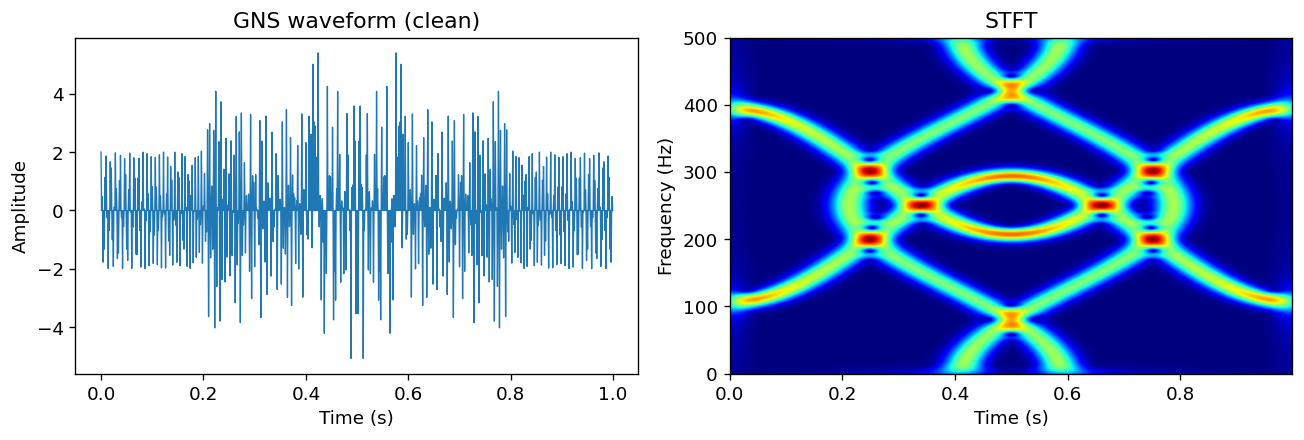

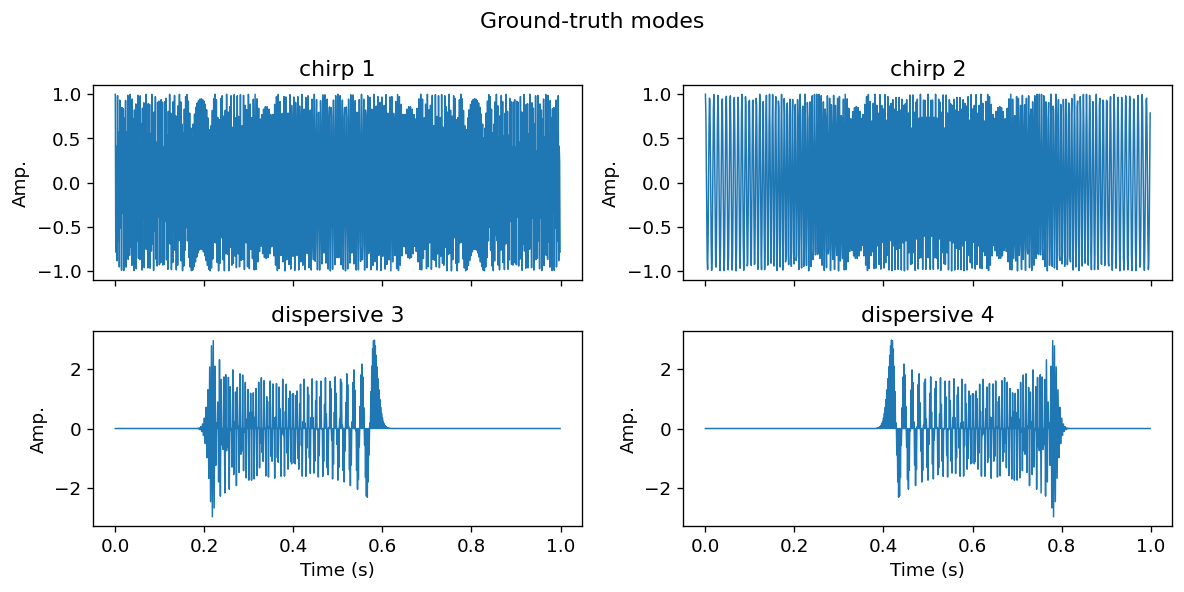

In [2]:
demo = make_ivgnmd_demo_signal(samp_freq=1000.0, noise_std=0.0)
t = demo["t"]
fs = float(demo["fs"][0])
signal = demo["signal"]
true_modes = demo["modes_true"]

spec, f_stft = stft_vgnmd(signal, fs, n_freq=len(signal), win_len=fs / 6.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t, signal, lw=0.8)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("GNS waveform (clean)")
axes[1].imshow(
    spec,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], f_stft[0], f_stft[-1]],
    cmap="jet",
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("STFT")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True)
labels = ["chirp 1", "chirp 2", "dispersive 3", "dispersive 4"]
for ax, mode, lab in zip(axes.ravel(), true_modes, labels):
    ax.plot(t, mode, lw=0.9)
    ax.set_title(lab)
    ax.set_ylabel("Amp.")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 1].set_xlabel("Time (s)")
fig.suptitle("Ground-truth modes")
fig.tight_layout()
plt.show()

## 4. Run IVGNMD


In [3]:
decomp = IVGNMD(max_iter=150)
modes_t, modes_f, types, ridges, features, f, t_ax, i_spec, skeleton = (
    decomp.fit_transform(signal, fs, return_all=True)
)

print(f"recovered K = {modes_t.shape[0]} modes")
print("types (1=chirp, 2=dispersive):", types)

# match each true mode to the best estimated mode by |correlation|
print("\n|corr| vs ground truth:")
for i in range(true_modes.shape[0]):
    best = 0.0
    best_k = -1
    for k in range(modes_t.shape[0]):
        c = np.corrcoef(true_modes[i], modes_t[k])[0, 1]
        if np.isfinite(c) and abs(c) > best:
            best = abs(c)
            best_k = k
    print(f"  true mode {i+1} → est m{best_k+1}, |corr|={best:.3f}")

recovered K = 4 modes
types (1=chirp, 2=dispersive): [1 1 1 1]

|corr| vs ground truth:
  true mode 1 → est m2, |corr|=0.427
  true mode 2 → est m4, |corr|=0.411
  true mode 3 → est m3, |corr|=0.013
  true mode 4 → est m3, |corr|=0.012


### 4.1 Intermediate TF maps (ATFFC → SE → TFSC)


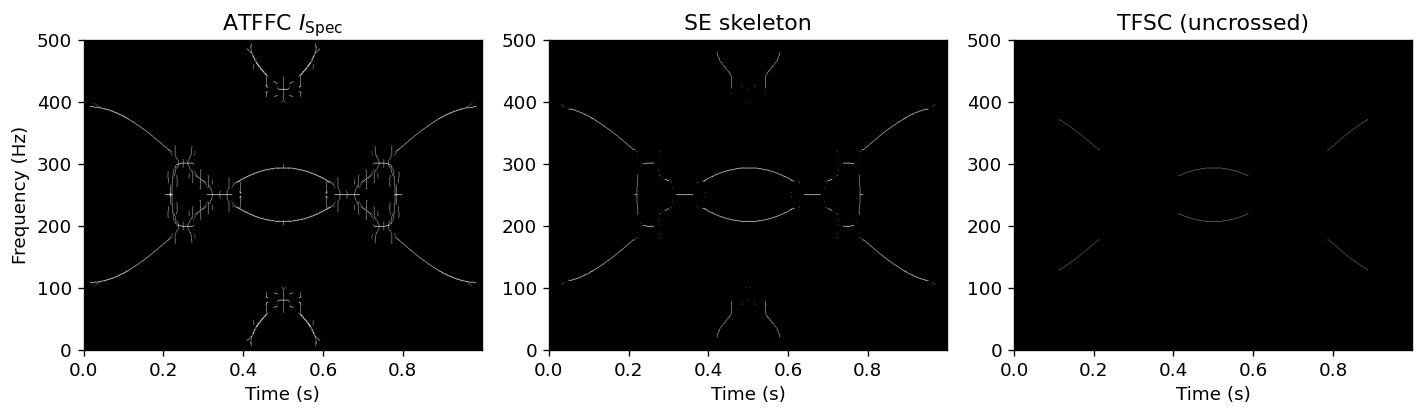

In [4]:
tfc = tfsc(skeleton)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, img, title in zip(
    axes,
    [i_spec, skeleton, tfc],
    ["ATFFC $I_{\\mathrm{Spec}}$", "SE skeleton", "TFSC (uncrossed)"],
):
    ax.imshow(
        img,
        aspect="auto",
        origin="lower",
        cmap="gray",
        extent=[t[0], t[-1], f[0], f[-1]],
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
fig.tight_layout()
plt.show()

### 4.2 Estimated modes vs truth


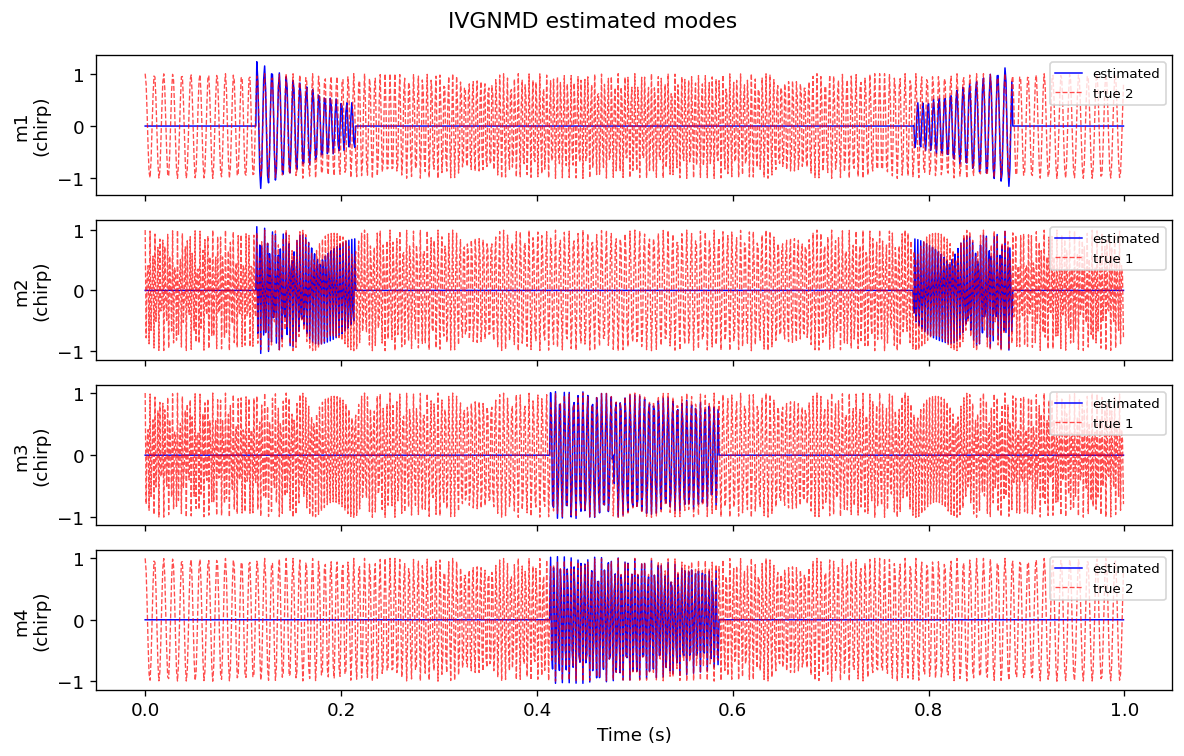

In [5]:
K = modes_t.shape[0]
fig, axes = plt.subplots(K, 1, figsize=(10, 1.6 * K), sharex=True)
if K == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    ax.plot(t_ax, modes_t[k], "b", lw=0.9, label="estimated")
    # overlay best-matching true mode
    best_i = int(
        np.argmax(
            [
                (
                    abs(np.corrcoef(true_modes[i], modes_t[k])[0, 1])
                    if np.isfinite(np.corrcoef(true_modes[i], modes_t[k])[0, 1])
                    else 0
                )
                for i in range(true_modes.shape[0])
            ]
        )
    )
    ax.plot(
        t_ax, true_modes[best_i], "r--", lw=0.8, alpha=0.7, label=f"true {best_i+1}"
    )
    kind = "chirp" if types[k] == 1 else "dispersive"
    ax.set_ylabel(f"m{k+1}\n({kind})")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("IVGNMD estimated modes")
fig.tight_layout()
plt.show()

### 4.3 Estimated IF / GD features


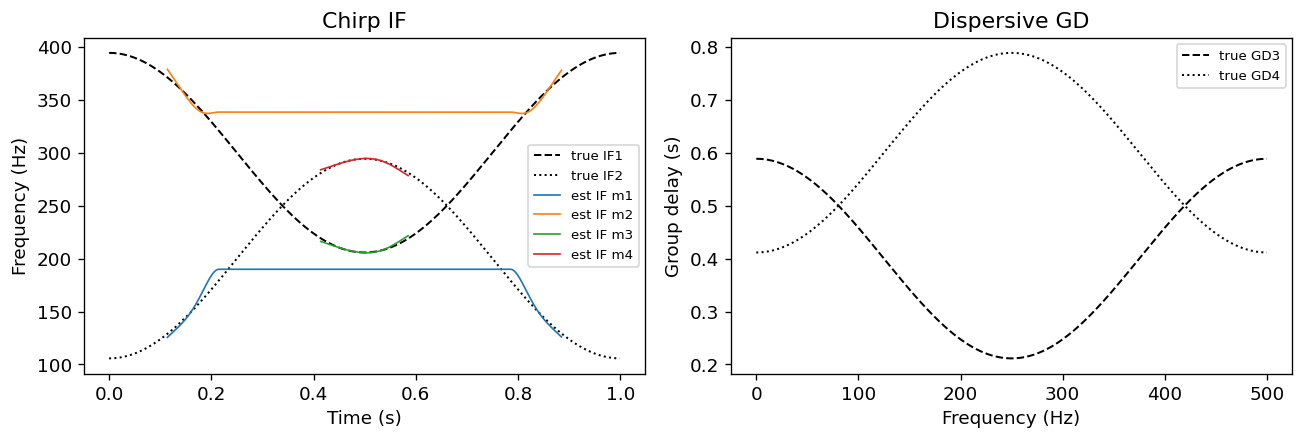

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t, demo["if1"], "k--", lw=1.2, label="true IF1")
axes[0].plot(t, demo["if2"], "k:", lw=1.2, label="true IF2")
for k, feat in enumerate(features):
    if types[k] == 1 and feat.size == t_ax.size:
        mask = feat > 0
        axes[0].plot(t_ax[mask], feat[mask], lw=1.0, label=f"est IF m{k+1}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Chirp IF")
axes[0].legend(fontsize=8)

axes[1].plot(demo["f_axis"], demo["gd3"], "k--", lw=1.2, label="true GD3")
axes[1].plot(demo["f_axis"], demo["gd4"], "k:", lw=1.2, label="true GD4")
for k, feat in enumerate(features):
    if types[k] == 2 and feat.size == f.size:
        mask = feat > 0
        axes[1].plot(f[mask], feat[mask], lw=1.0, label=f"est GD m{k+1}")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Group delay (s)")
axes[1].set_title("Dispersive GD")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Noisy case (optional)

MATLAB `Test.m` adds Gaussian noise with $\mathrm{STD}=0.2$ (~$-3\,$dB per mode).


noisy run: recovered 2 modes


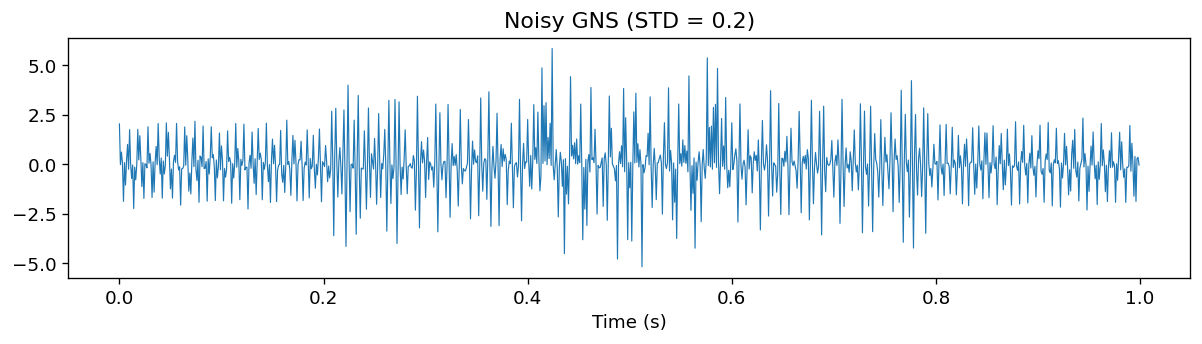

In [7]:
demo_n = make_ivgnmd_demo_signal(
    samp_freq=1000.0, noise_std=0.2, rng=np.random.default_rng(0)
)
modes_n = IVGNMD(max_iter=120).fit_transform(demo_n["signal"], fs)
print("noisy run: recovered", modes_n.shape[0], "modes")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(demo_n["t"], demo_n["signal"], lw=0.7)
ax.set_title("Noisy GNS (STD = 0.2)")
ax.set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 6. Parameter cheat-sheet (MATLAB ↔ PySDKit)

| MATLAB (`IVGNMD.m`) | `IVGNMD` | Role |
|---|---|---|
| `Tp = 6` | `tp` | ATFFC window scale `fs/(i·Tp)` |
| `H = 60` | `spur_len` | SE spur length (default 40 in Python for stability) |
| `alpha`, `beta` | `alpha`, `beta` | VOA / ACMD / GDMD penalties (`5e-7`, `0.5e-5`) |
| `tol = 1e-30` | `tol` | VOA convergence |
| skeleton stop `< 100` px | `min_skeleton_pixels` | TFST loop stop |

```python
from pysdkit import IVGNMD
modes = IVGNMD()(signal, fs)          # shape (K, N)
modes, *_ = IVGNMD()(signal, fs, return_all=True)
```
